# Clase Nº 4: Aprendizaje Supervisado
-----
###Flujo de Trabajo:
1. Actividad - Regresión Lineal encontrar un dataset de tu interés que contenga como variable objetivo una variable continua y aplicar la regresión lineal simple y multiple para intentar predecir.

Dataset de ejercicio- kaggle: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database


Variable elegidas, X = BMI(el peso y la composición corporal son factores de riesgo preexistentes; Y = Glucosa(los niveles de azúcar en sangre suelen ser una consecuencia del estado físico y metabólico.
El método que seguiremos es el siguiente:

●      Preparación y organización de datos
●      Exploración de los datos
●      Modelado de datos

In [4]:
#carga de datos
import pandas as pd
import numpy as np
dat_csv = pd.read_csv('diabetes.csv', encoding= 'iso-8859-1')
print (dat_csv)
dat_csv.head()

print(f'Dimensiones: {dat_csv.shape[0]} filas x {dat_csv.shape[1]} columnas')




     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [5]:
# Cuenta cuántos ceros hay en cada columna
nulos_glucose = (dat_csv['Glucose'] == 0).sum()
nulos_bmi = (dat_csv['BMI'] == 0).sum()

print(f"Valores en cero en Glucose: {nulos_glucose}")
print(f"Valores en cero en BMI: {nulos_bmi}")

Valores en cero en Glucose: 5
Valores en cero en BMI: 11


##### Como el dataset diabetes.csv tiene dimensión de 768 registros y los ceros en Glucose o BMI son pocos(2%), decido eliminar esos registros para no sesgar la pendiente de mi recta.

In [6]:
# Crear una copia del dataframe original para no perder datos
# Filtramos donde Glucose y BMI sean mayores a 0
df_ejercicio = dat_csv[(dat_csv['Glucose'] > 0) & (dat_csv['BMI'] > 0)].copy()

# Ahora revisa con describe() y verás que el 'count' bajó un poco, 
# pero el 'min' ya es un valor biológicamente posible.
print(df_ejercicio[['Glucose', 'BMI']].describe())

          Glucose         BMI
count  752.000000  752.000000
mean   121.941489   32.454654
std     30.601198    6.928926
min     44.000000   18.200000
25%     99.750000   27.500000
50%    117.000000   32.300000
75%    141.000000   36.600000
max    199.000000   67.100000


In [7]:
# 2. Declaramos las variables
# Usamos doble corchete [[ ]] para X para que sea un DataFrame (2D)
x = df_ejercicio['BMI'] 
y = df_ejercicio['Glucose']
x = []
y = []
for i in df_ejercicio['BMI']:
    x.append(i)
for i in df_ejercicio['Glucose']:
    y.append(i)
print(x)
print(y)
X = np.array(x)
Y = np.array(y)
# 3. Verificamos que todo esté bien
print(f"Forma de X: {X.shape}") # Debería decir (n_filas, 1)
print(f"Forma de y: {Y.shape}") # Debería decir (n_filas,)

[33.6, 26.6, 23.3, 28.1, 43.1, 25.6, 31.0, 35.3, 30.5, 37.6, 38.0, 27.1, 30.1, 25.8, 30.0, 45.8, 29.6, 43.3, 34.6, 39.3, 35.4, 39.8, 29.0, 36.6, 31.1, 39.4, 23.2, 22.2, 34.1, 36.0, 31.6, 24.8, 19.9, 27.6, 24.0, 33.2, 32.9, 38.2, 37.1, 34.0, 40.2, 22.7, 45.4, 27.4, 42.0, 29.7, 28.0, 39.1, 19.4, 24.2, 24.4, 33.7, 34.7, 23.0, 37.7, 46.8, 40.5, 41.5, 32.9, 25.0, 25.4, 32.8, 29.0, 32.5, 42.7, 19.6, 28.9, 32.9, 28.6, 43.4, 35.1, 32.0, 32.6, 37.7, 43.2, 25.0, 22.4, 29.3, 24.6, 48.8, 32.4, 36.6, 38.5, 37.1, 26.5, 19.1, 32.0, 46.7, 23.8, 24.7, 33.9, 31.6, 20.4, 28.7, 49.7, 39.0, 26.1, 22.5, 26.6, 39.6, 28.7, 22.4, 29.5, 34.3, 37.4, 33.3, 34.0, 31.2, 34.0, 30.5, 31.2, 34.0, 33.7, 28.2, 23.2, 53.2, 34.2, 33.6, 26.8, 33.3, 55.0, 42.9, 33.3, 34.5, 27.9, 29.7, 33.3, 34.5, 38.3, 21.1, 33.8, 30.8, 28.7, 31.2, 36.9, 21.1, 39.5, 32.5, 32.4, 32.8, 32.8, 30.5, 33.7, 27.3, 37.4, 21.9, 34.3, 40.6, 47.9, 50.0, 24.6, 25.2, 29.0, 40.9, 29.7, 37.2, 44.2, 29.7, 31.6, 29.9, 32.5, 29.6, 31.9, 28.4, 30.8, 35.4, 28.

In [8]:
# Calculo (80% para entrenamiento, 20% para prueba)
datos_entrenamiento = int(0.8 * len(X))
datos_prueba = len(X) - datos_entrenamiento
print(f"Datos para entrenamiento: {datos_entrenamiento}")
print(f"Datos para prueba: {datos_prueba}")

# Datos de entrenamiento
X_train = X[:datos_entrenamiento].reshape((datos_entrenamiento,1))
Y_train = Y[:datos_entrenamiento].reshape((datos_entrenamiento,1))

print(X_train)
print(Y_train)

# Datos de prueba
X_test = X[datos_entrenamiento:].reshape((datos_prueba,1))
Y_test = Y[datos_entrenamiento:].reshape((datos_prueba,1))
print(X_test)
print(Y_test)

Datos para entrenamiento: 601
Datos para prueba: 151
[[33.6]
 [26.6]
 [23.3]
 [28.1]
 [43.1]
 [25.6]
 [31. ]
 [35.3]
 [30.5]
 [37.6]
 [38. ]
 [27.1]
 [30.1]
 [25.8]
 [30. ]
 [45.8]
 [29.6]
 [43.3]
 [34.6]
 [39.3]
 [35.4]
 [39.8]
 [29. ]
 [36.6]
 [31.1]
 [39.4]
 [23.2]
 [22.2]
 [34.1]
 [36. ]
 [31.6]
 [24.8]
 [19.9]
 [27.6]
 [24. ]
 [33.2]
 [32.9]
 [38.2]
 [37.1]
 [34. ]
 [40.2]
 [22.7]
 [45.4]
 [27.4]
 [42. ]
 [29.7]
 [28. ]
 [39.1]
 [19.4]
 [24.2]
 [24.4]
 [33.7]
 [34.7]
 [23. ]
 [37.7]
 [46.8]
 [40.5]
 [41.5]
 [32.9]
 [25. ]
 [25.4]
 [32.8]
 [29. ]
 [32.5]
 [42.7]
 [19.6]
 [28.9]
 [32.9]
 [28.6]
 [43.4]
 [35.1]
 [32. ]
 [32.6]
 [37.7]
 [43.2]
 [25. ]
 [22.4]
 [29.3]
 [24.6]
 [48.8]
 [32.4]
 [36.6]
 [38.5]
 [37.1]
 [26.5]
 [19.1]
 [32. ]
 [46.7]
 [23.8]
 [24.7]
 [33.9]
 [31.6]
 [20.4]
 [28.7]
 [49.7]
 [39. ]
 [26.1]
 [22.5]
 [26.6]
 [39.6]
 [28.7]
 [22.4]
 [29.5]
 [34.3]
 [37.4]
 [33.3]
 [34. ]
 [31.2]
 [34. ]
 [30.5]
 [31.2]
 [34. ]
 [33.7]
 [28.2]
 [23.2]
 [53.2]
 [34.2]
 [33.6]
 [2

In [9]:
# Instalamos la librería de regresión lineal
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Realizamos la regresión lineal

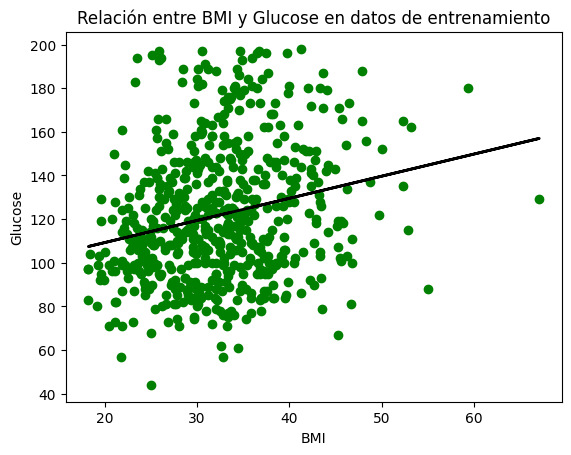

In [50]:
from sklearn import linear_model


# Creamos un objeto de regresión lineal
linear_regressor = linear_model.LinearRegression()
linear_regressor.fit(X_train, Y_train)

Y_predicha_de_entrenamiento = linear_regressor.predict(X_train)

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_train, Y_train, color='green')
plt.xlabel('BMI')
plt.ylabel('Glucose')
plt.plot(X_train, Y_predicha_de_entrenamiento, color='black', linewidth=2)
plt.title('Relación entre BMI y Glucose en datos de entrenamiento')
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

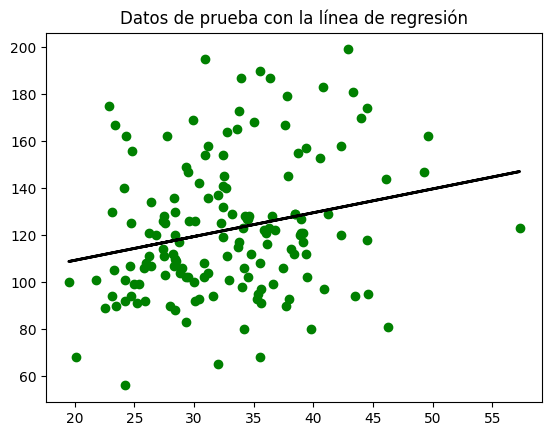

In [17]:
Y_predicha_de_prueba = linear_regressor.predict(X_test)
plt.figure()
plt.scatter(X_test, Y_test, color='green')
plt.plot(X_test, Y_predicha_de_prueba, color='black', linewidth=2)
plt.title('Datos de prueba con la línea de regresión')
plt.show

intercepto = [89.00140319]
coeficiente = [[1.01309641]]
Error absoluto medio = 22.35
Error cuadrático medio = 792.16
Error absoluto mediano = 17.87
Puntuación de varianza explicada = 0.06
Puntuación R2 = 0.06


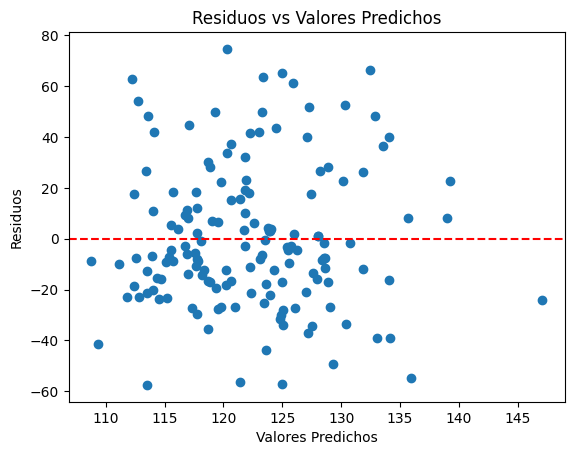

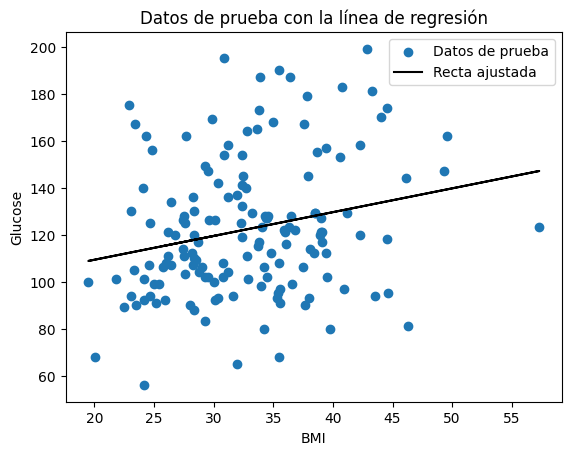

In [56]:
import sklearn.metrics as sm
print("intercepto =", linear_regressor.intercept_)
print("coeficiente =", linear_regressor.coef_)
print("Error absoluto medio =", round(sm.mean_absolute_error(Y_test, Y_predicha_de_prueba), 2))
print("Error cuadrático medio =", round(sm.mean_squared_error(Y_test, Y_predicha_de_prueba), 2))
print("Error absoluto mediano =", round(sm.median_absolute_error(Y_test, Y_predicha_de_prueba), 2))
print("Puntuación de varianza explicada =", round(sm.explained_variance_score(Y_test, Y_predicha_de_prueba), 2))
print("Puntuación R2 =", round(sm.r2_score(Y_test, Y_predicha_de_prueba), 2))

residuos = Y_test - Y_predicha_de_prueba
plt.scatter(Y_predicha_de_prueba, residuos)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores Predichos')
plt.show()

plt.scatter(X_test, Y_test, label='Datos de prueba')
plt.plot(X_test, Y_predicha_de_prueba, color='black', label='Recta ajustada')
plt.xlabel('BMI')
plt.ylabel('Glucose')
plt.legend()
plt.title('Datos de prueba con la línea de regresión')
plt.show()

### Análisis de Regresión Lineal Simple
 Glucosa-BMI: estudio se centró en determinar si el Índice de Masa Corporal (BMI) puede predecir los niveles de Glucosa en sangre.  La Ecuación del Modelo: Se observa que la relación indica que la glucosa base comienza en 89.00 mg/dL y aumenta aproximadamente 1 unidad por cada punto de BMI. El modelo tiene un coeficiente de determinación de 0.06, significa que el BMI solo explica el 6% de la variación de la glucosa, lo que sugiere que existen otros factores (como la edad) que influyen. 
 Precisión de las Predicciones:El error promedio (MAE) es de 22.35 unidades.El Error Mediano (17.87) es menor al promedio, lo que indica que el modelo es más preciso en la mayoría de los casos, pero se ve afectado por algunos valores extremos o "outliers".
 Tratamiento de Datos: Para asegurar la validez de estos resultados, se filtraron registros inconsistentes (valores en cero) en las variables clave.  
 
 Aunque la relación es estadísticamente positiva, la Regresión Lineal Simple es insuficiente para un diagnóstico preciso. 
 Por ende los resultados respaldan la necesidad de evolucionar hacia una Regresión Múltiple para integrar variables adicionales y mejorar el porcentaje de varianza explicada.

## *Regresión lineal multiple*

In [61]:
# Agregamos la variable 'Age' a nuestro modelo
x = df_ejercicio[['BMI', 'Age']]
y = df_ejercicio['Glucose']
print(x)
print(y)

      BMI  Age
0    33.6   50
1    26.6   31
2    23.3   32
3    28.1   21
4    43.1   33
..    ...  ...
763  32.9   63
764  36.8   27
765  26.2   30
766  30.1   47
767  30.4   23

[752 rows x 2 columns]
0      148
1       85
2      183
3       89
4      137
      ... 
763    101
764    122
765    121
766    126
767     93
Name: Glucose, Length: 752, dtype: int64


Descripción estadística:
              Age         BMI     Glucose
count  752.000000  752.000000  752.000000
mean    33.312500   32.454654  121.941489
std     11.709395    6.928926   30.601198
min     21.000000   18.200000   44.000000
25%     24.000000   27.500000   99.750000
50%     29.000000   32.300000  117.000000
75%     41.000000   36.600000  141.000000
max     81.000000   67.100000  199.000000


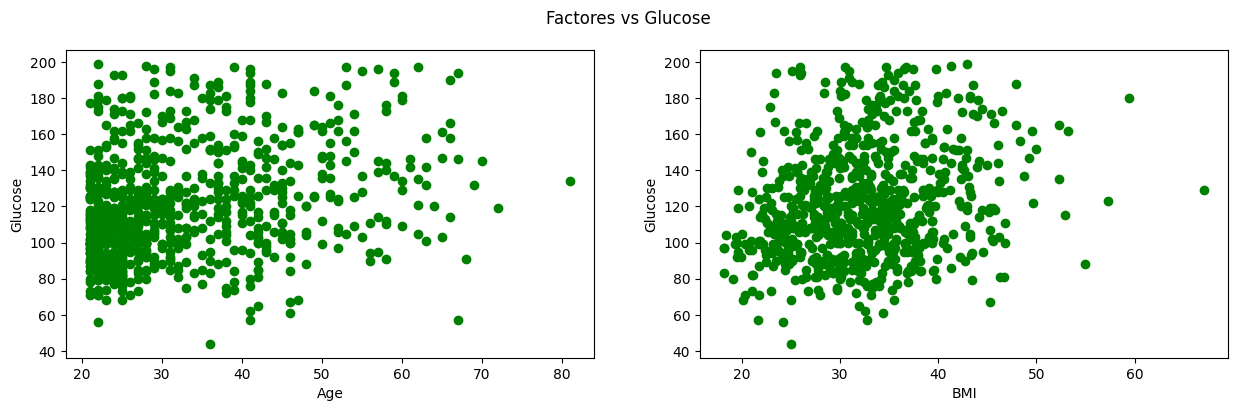

In [68]:
print("Descripción estadística:")
print(df_ejercicio[['Age', 'BMI', 'Glucose']].describe())

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].scatter(df_ejercicio['Age'], df_ejercicio['Glucose'], color='green')
axs[0].set_xlabel("Age")
axs[0].set_ylabel("Glucose")

axs[1].scatter(df_ejercicio['BMI'], df_ejercicio['Glucose'], color='green')
axs[1].set_xlabel("BMI")
axs[1].set_ylabel("Glucose")

plt.suptitle("Factores vs Glucose")
plt.show()

In [72]:

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

y_pred_multiple = model_multiple.predict(X_test)

Intercepto: 65.9748390717098
Coeficientes: [0.67494969 1.0111443 ]

Evaluación del modelo (Regresión Múltiple):
MAE: 23.526837580873725
MSE: 894.8469089248022
R²: 0.0895990133973309
Varianza explicada: 0.10079285516984793


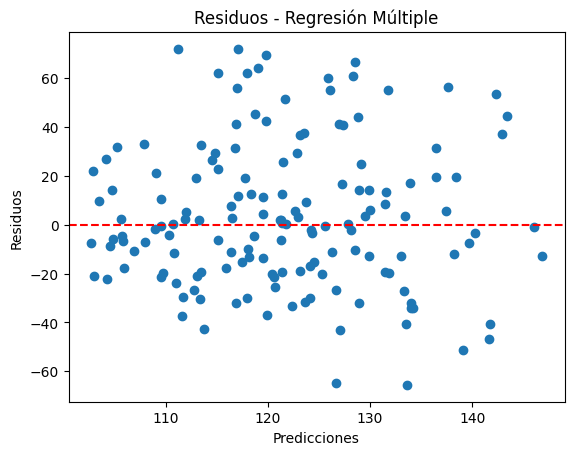

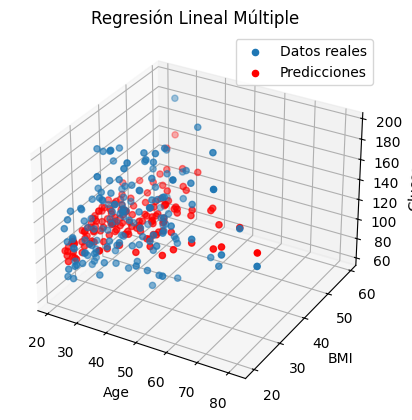

In [74]:
print("Intercepto:", model_multiple.intercept_)
print("Coeficientes:", model_multiple.coef_)

print("\nEvaluación del modelo (Regresión Múltiple):")
print("MAE:", mean_absolute_error(y_test, y_pred_multiple))
print("MSE:", mean_squared_error(y_test, y_pred_multiple))
print("R²:", r2_score(y_test, y_pred_multiple))
print("Varianza explicada:", explained_variance_score(y_test, y_pred_multiple))

residuos = y_test - y_pred_multiple
plt.scatter(y_pred_multiple, residuos)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos - Regresión Múltiple")
plt.show()

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test['Age'], X_test['BMI'], y_test, label="Datos reales")
ax.scatter(X_test['Age'], X_test['BMI'], y_pred_multiple, color='red', label="Predicciones")
ax.set_xlabel("Age")
ax.set_ylabel("BMI")
ax.set_zlabel("Glucose")
plt.title("Regresión Lineal Múltiple")
plt.legend()
plt.show()


Al integrar más de una variable predictora, el modelo tiene visión más completa que el análisis simple anterior.

 El coeficiente de determinación subió a 0.089 (aprox. 9%). Comparado con el 6% del modelo simple, la inclusión de una segunda variable mejoró la capacidad de explicación del modelo en un 50% relativo.
 Varianza Explicada: Este valor alcanza el 10%, lo que confirma que el modelo es ahora más robusto para capturar las diferencias entre los pacientes.}Métricas de Error:MAE (23.52): El error promedio por predicción se mantiene en un rango similar, lo que es coherente al trabajar con datos biológicos de alta dispersión.MSE (894.84), la métrica refleja valores atípicos que el modelo aún está aprendiendo a procesar.
La transición de la regresión simple a la múltiple mejoro y logra elevar la varianza explicada del 6% al 10%. Demuestra que la glucosa no depende de un solo factor, sino de una combinación de variables.